In [1]:
import sys

print(sys.executable)

c:\python312\python.exe


In [2]:
import pandas as pd

df = pd.read_csv("data/r_dataisbeautiful_posts.csv")

df.head()

C:\Users\palak\AppData\Local\Temp\ipykernel_74912\1946044778.py:3: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/r_dataisbeautiful_posts.csv")


,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
0,ll1p9h,Wordcloud of trending video titles on YouTube ...,1,OmarZiada,OC: 1,NaN,0.0,[],1613473961,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
1,ll1o4h,Wordcloud of trending videos on YouTube in the...,1,OmarZiada,OC: 1,moderator,0.0,[],1613473829,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
2,ll15gx,Immunization in India. Source: https://niti.go...,1,Professional_Napper_,NaN,moderator,0.0,[],1613471541,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
3,ll0iup,How to quickly estimate the impact of players ...,1,Viziball,NaN,automod_filtered,0.0,[],1613468624,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
4,ll0g9a,How to quickly estimate the impact of players ...,1,Viziball,NaN,moderator,0.0,[],1613468281,https://www.reddit.com/r/dataisbeautiful/comme...,2,False


In [3]:
df["removed_by"].value_counts(dropna = False)

removed_by
NaN                 170109
moderator            14789
deleted               2948
automod_filtered      1553
reddit                1453
author                   1
Name: count, dtype: int64

# Understanding the Target Variable

Before developing a machine learning model, it is essential to identify and understand the target variable.

In this dataset, the `removed_by` column indicates whether a Reddit post was removed and, in some cases, identifies the entity responsible for the removal. To explore the possible values within this column, the `value_counts(dropna=False)` function was used to display all unique values, including missing values (`NaN`).

# Dataset Overview

Before conducting exploratory data analysis (EDA) and preprocessing, the structure of the dataset was examined to gain an understanding of its composition and quality.

The initial inspection included:

* Number of rows
* Number of columns
* Data types of each feature
* Missing value analysis

This assessment helps identify potential data quality issues, understand the characteristics of individual variables, and determine which columns may require cleaning, transformation, or further preprocessing before model development.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190853 entries, 0 to 190852
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     190853 non-null  object 
 1   title                  190852 non-null  object 
 2   score                  190853 non-null  int64  
 3   author                 190853 non-null  object 
 4   author_flair_text      28845 non-null   object 
 5   removed_by             20744 non-null   object 
 6   total_awards_received  65146 non-null   float64
 7   awarders               54478 non-null   object 
 8   created_utc            190853 non-null  int64  
 9   full_link              190853 non-null  object 
 10  num_comments           190853 non-null  int64  
 11  over_18                190853 non-null  bool   
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 16.2+ MB


# Creating the Target Variable

Machine learning models require a numerical target variable for classification tasks.

The original `removed_by` column contained textual information indicating whether a Reddit post had been removed by moderators. To make the data suitable for supervised learning, this information was transformed into a binary target variable:

* **0** → Post not removed
* **1** → Post removed

This process, commonly referred to as **target engineering**, converts the outcome into a machine-readable format while preserving the underlying moderation outcome recorded in the dataset.


In [5]:
df["removed"] = df["removed_by"].notna().astype(int)
df["removed"].value_counts()

removed
0    170109
1     20744
Name: count, dtype: int64

# Missing Value Analysis

Missing value analysis is performed to assess data quality and identify columns that may require cleaning, imputation, or removal.

Understanding the extent of missing data helps guide feature selection and preprocessing decisions.

In [6]:
df.isnull().sum().sort_values(ascending = False)

removed_by               170109
author_flair_text        162008
awarders                 136375
total_awards_received    125707
title                         1
id                            0
score                         0
author                        0
created_utc                   0
full_link                     0
num_comments                  0
over_18                       0
removed                       0
dtype: int64

# Target Variable Distribution

Before building the machine learning model, the distribution of the target variable was examined.

This analysis helps identify potential class imbalance and provides insight into the proportion of removed and non-removed posts within the dataset.

In [7]:
(df["removed"].value_counts(normalize=True)*100).round(2)

removed
0    89.13
1    10.87
Name: proportion, dtype: float64

# Investigating Award Information

The `total_awards_received` column contains a large number of missing values.

Before removing the column, it is important to determine whether missing values represent genuinely unavailable information or simply indicate that a post received no awards.

This distinction affects how the feature should be treated during preprocessing.

In [8]:
df["total_awards_received"].describe()

count    65146.000000
mean         0.013109
std          0.589425
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         93.000000
Name: total_awards_received, dtype: float64

# Investigating Award Counts

The statistical summary suggests that awards are extremely rare.

To better understand the feature, the unique values and their frequencies are inspected.

This helps determine whether missing values should be interpreted as zero awards and whether the feature contains useful information for modeling.

In [9]:
df["total_awards_received"].value_counts(dropna=False).head(20)

total_awards_received
NaN     125707
0.0      64947
1.0        118
2.0         21
3.0         14
4.0          8
6.0          7
5.0          7
15.0         4
8.0          4
7.0          2
21.0         1
12.0         1
18.0         1
14.0         1
27.0         1
30.0         1
93.0         1
11.0         1
9.0          1
Name: count, dtype: int64

# Feature Selection: Award-Related Columns

Investigation of the award-related features revealed that awards are extremely rare.

Findings:

- More than 84% of rows contain missing values.
- Almost all non-missing observations contain 0 awards.
- Only a handful of posts received any awards.

Given the extremely low variance and high proportion of missing values, the columns `total_awards_received` and `awarders` are removed from further analysis.

This simplifies the dataset without losing meaningful predictive information.

In [10]:
df.columns.tolist()

['id',
 'title',
 'score',
 'author',
 'author_flair_text',
 'removed_by',
 'total_awards_received',
 'awarders',
 'created_utc',
 'full_link',
 'num_comments',
 'over_18',
 'removed']

# Initial Feature Selection

Based on the exploratory investigation:

Removed columns:

- `id`
- `full_link`
- `removed_by`
- `awarders`
- `total_awards_received`

Reasons:

- Data leakage
- Excessive missing values
- Limited predictive value

The resulting dataframe will be used for further exploratory analysis and feature engineering.

In [11]:
df_clean = df.drop(
    columns = [
        "id",
        "full_link",
        "removed_by",
        "awarders",
        "total_awards_received"
    ]
)
df_clean.head()

,title,score,author,author_flair_text,created_utc,num_comments,over_18,removed
0,Wordcloud of trending video titles on YouTube ...,1,OmarZiada,OC: 1,1613473961,0,False,0
1,Wordcloud of trending videos on YouTube in the...,1,OmarZiada,OC: 1,1613473829,1,False,1
2,Immunization in India. Source: https://niti.go...,1,Professional_Napper_,NaN,1613471541,1,False,1
3,How to quickly estimate the impact of players ...,1,Viziball,NaN,1613468624,0,False,1
4,How to quickly estimate the impact of players ...,1,Viziball,NaN,1613468281,2,False,1


# Comparing Removed and Non-Removed Posts

## Objective

Determine whether removed posts differ from non-removed posts in terms of community engagement.

## Methodology

Posts are grouped according to the target variable (`removed`).

The average score and average number of comments are calculated for each group.

## Interpretation

Large differences between the groups may indicate that engagement-related features contain predictive information useful for moderation classification.

In [12]:
df.groupby("removed")[["score","num_comments"]].mean()

,score,num_comments
removed,,
0,196.445943,30.630531
1,8.483851,2.791988


## Results

| Removed | Average Score | Average Comments |
|----------|----------|----------|
| 0 (Not Removed) | 196.45 | 30.63 |
| 1 (Removed) | 8.48 | 2.79 |

## Interpretation

Non-removed posts receive substantially higher engagement than removed posts.

On average:

- Non-removed posts receive approximately **23 times more upvotes**.
- Non-removed posts receive approximately **11 times more comments**.

These findings indicate that posts with stronger community engagement are significantly more likely to be removed. The large differences in both score and comment count suggest that engagement-based features may provide valuable predictive signals for moderation classification.

## Conclusion

Community engagement metrics such as post score and comment count exhibit a strong relationship with moderation outcomes. These variables are therefore likely to be important features for predicting whether a Reddit post will be removed.

# Score Distribution Analysis

## Objective

To understand the distribution of post scores.

## Methodology

 Descriptive statistics are computed for the `score` feature.

## Interpretation

The presence of extreme values may influence averages and affect subsequent analyses.

Understanding the distribution helps determine whether mean-based comparisons are reliable.

In [13]:
df_clean["score"].describe()

count    190853.000000
mean        176.016159
std        1951.936524
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max      116226.000000
Name: score, dtype: float64

## Results

- Mean score: **176.02**
- Median score: **1**
- 75th percentile: **4**
- Maximum score: **116,226**

## Interpretation

The score distribution is highly right-skewed.

Most posts receive relatively few upvotes, as indicated by the median score of only 1 and a 75th percentile of 4. However, a small number of highly popular posts achieve exceptionally large scores, resulting in a maximum score of 116,226.

These extreme values substantially increase the mean score, causing it to be much larger than the median. This suggests the presence of significant outliers and indicates that the mean is not representative of a typical post.

## Conclusion

The distribution of post scores is dominated by a small number of viral submissions, while the majority of posts receive limited engagement. Due to the strong skewness and presence of outliers, log transformation is later applied to the score feature before model training.

# Visualizing the Score Distribution

## Objective

To visualize the distribution of post scores.

## Methodology

A histogram is plotted using scores up to the 99th percentile.

Extreme outliers are temporarily excluded from the visualization to reveal the structure of the majority of the data.

## Interpretation

The resulting plot helps identify skewness, concentration of observations, and potential outliers.

<Axes: >

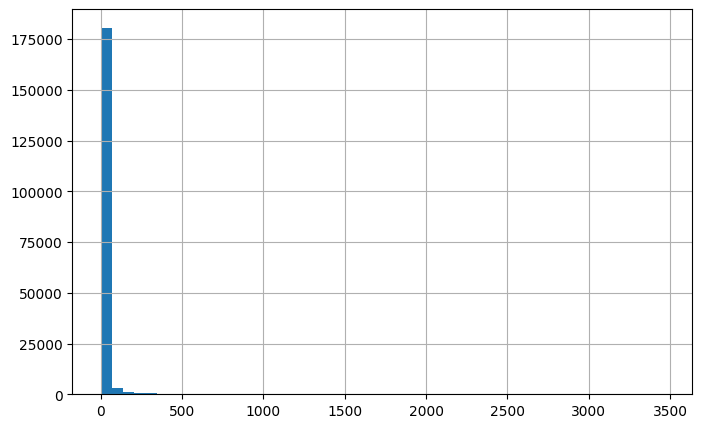

In [14]:
score_99 = df_clean["score"].quantile(0.99)

df_clean[df_clean["score"] <= score_99]["score"].hist(
    bins=50,
    figsize=(8,5)
)

# Interpretation of Score Distribution

## Findings

The score distribution is highly right-skewed.

Most posts receive very few upvotes, while a relatively small number of posts achieve exceptionally high scores.

### Evidence

* Mean score = 176.02
* Median score = 1
* 75th percentile = 4
* Maximum score = 116,226

The large gap between the mean and median indicates the presence of extreme outliers that substantially influence the overall distribution.

## Implications

The mean score is heavily affected by a small number of highly popular posts and therefore does not accurately represent a typical Reddit submission.

For this dataset, median-based statistics provide a more reliable measure of central tendency than the mean.

The strong skewness and presence of extreme outliers suggest that transformations such as logarithmic scaling may be beneficial during feature engineering and model development.


# Median Comparison of Engagement Metrics

## Objective

To compare typical engagement levels between removed and non-removed posts.

## Methodology

Median values are computed instead of means because the score distribution contains extreme outliers.

Median statistics are more robust and better represent a typical observation in skewed datasets.

## Interpretation

Differences in median engagement may indicate whether community response is associated with moderation outcomes.

In [15]:
df_clean.groupby("removed")[["score", "num_comments"]].median()

,score,num_comments
removed,,
0,1.0,2.0
1,1.0,2.0


# Mean vs Median Analysis

## Findings

A substantial difference exists between the mean and median engagement metrics for both removed and non-removed posts.

| Metric          | Non-Removed | Removed |
| --------------- | ----------- | ------- |
| Mean Score      | 196.45      | 8.48    |
| Median Score    | 1           | 1       |
| Mean Comments   | 30.63       | 2.79    |
| Median Comments | 1           | 2       |

## Interpretation

The large gaps between mean and median values indicate the presence of significant outliers within the dataset.

Although non-removed posts have much higher average scores and comment counts, the median values remain relatively low for both groups. This suggests that the majority of Reddit posts receive limited engagement, while a small number of highly popular posts substantially increase the averages.

For scores, both removed and non-removed posts share the same median value of 1, despite large differences in their means. This highlights the strong influence of viral posts on the score distribution.

Similarly, comment counts exhibit a highly skewed distribution, with average values being much larger than their corresponding medians.

# Score Distribution by Moderation Outcome

## Objective

To compare score distributions between removed and non-removed posts.

## Methodology

A boxplot is used to visualize the spread, median, and outliers of post scores for each moderation outcome.

## Interpretation

Differences in the distributions may indicate whether score is associated with the likelihood of post removal.

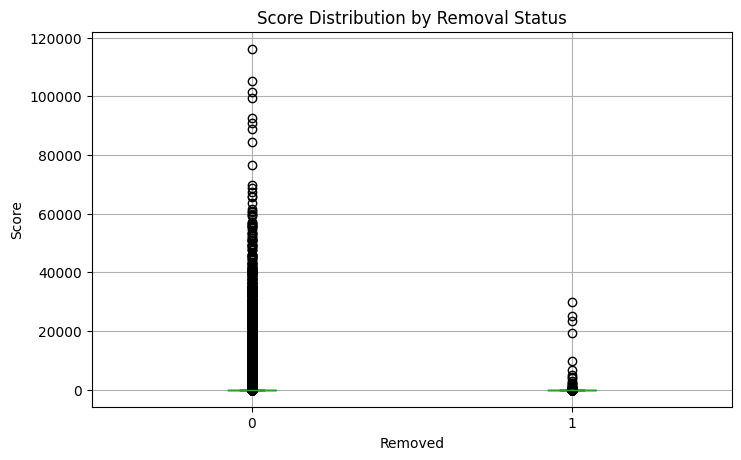

In [16]:
import matplotlib.pyplot as plt

df_clean.boxplot(column="score", by="removed", figsize=(8,5))

plt.title("Score Distribution by Removal Status")
plt.suptitle("")
plt.xlabel("Removed")
plt.ylabel("Score")
plt.show()

# Boxplot Analysis of Post Scores

## Findings

The score distributions contain a large number of extreme outliers.

Non-removed posts exhibit substantially more high-scoring outliers than removed posts.

## Interpretation

The presence of viral posts causes strong right-skewness in the score distribution.

Although the median scores are similar between the two groups, non-removed posts have a much greater potential to achieve very high scores.

This suggests that highly successful posts are rarely removed by moderators.

In [17]:
df_clean["title"].sample(10,random_state=42)

30391     This website sums up your entire life in stati...
145116    How Big Data Creates False Confidence - Facts ...
134910                               Visualizing Hurricanes
153922                         Star Wars Sentiment Analysis
49873     Visual comparison of global revenue - Apple vs...
97535     Donald Trump's and Chief of Staff Tweets by Ti...
100240    Napoleon was the Best General Ever, and the Ma...
47087                    Data Science Team: How to Make One
49445     I shuffled my 301 song playlist and got 4 Beat...
2086      [OC] I sent out over 100 applications during m...
Name: title, dtype: object

# Raw Text Inspection

## Objective

To examine a sample of Reddit post titles before applying any text preprocessing techniques.

## Methodology

A random sample of titles was selected using the `sample()` function.

## Findings

The titles contain:

- Uppercase and lowercase text
- Numbers
- Abbreviations such as `[OC]`
- Punctuation marks
- Multi-word phrases
- Geographic names
- Domain-specific terms

## Interpretation

The text appears relatively clean and structured. However, several preprocessing steps may still be beneficial before converting text into numerical features.

# Most Frequent Words in Post Titles

## Objective

To identify commonly occurring words in Reddit post titles.

## Methodology

The title text is converted to lowercase and split into individual words.

Word frequencies are then calculated.

In [18]:
from collections import Counter

all_words = " ".join(df_clean["title"].dropna()).lower().split()

Counter(all_words).most_common(20)

[('the', 80883),
 ('of', 70458),
 ('[oc]', 64997),
 ('in', 48381),
 ('and', 31952),
 ('to', 28473),
 ('a', 28225),
 ('by', 19762),
 ('for', 17224),
 ('on', 15325),
 ('-', 14269),
 ('is', 13025),
 ('from', 12707),
 ('my', 12236),
 ('i', 12185),
 ('data', 11457),
 ('how', 10861),
 ('with', 9157),
 ('this', 8175),
 ('most', 7728)]

# Investigating the [OC] Tag

## Objective

To determine whether the presence of the `[OC]` (Original Content) tag is associated with moderation outcomes.

## Methodology

A new binary feature is created indicating whether a title contains the `[OC]` tag.

The proportion of removed and non-removed posts is then compared.

## Interpretation

If the removal rates differ substantially, the `[OC]` tag may contain predictive information and should be preserved during preprocessing.

In [19]:
df_clean["has_oc"] = df_clean["title"].str.contains(
    r"\[oc\]",
    case=False,
    na=False
)

pd.crosstab(
    df_clean["has_oc"],
    df_clean["removed"],
    normalize="index"
) * 100

removed,0,1
has_oc,,
False,85.637625,14.362375
True,95.626573,4.373427


## Results

| Has [OC] | Not Removed (%) | Removed (%) |
| -------- | --------------- | ----------- |
| False    | 85.64           | 14.36       |
| True     | 95.63           | 4.37        |

## Interpretation

Posts marked as **Original Content ([OC])** exhibit a substantially lower removal rate than posts without the tag.

While approximately **14.36%** of non-OC posts are removed, only **4.37%** of OC posts are removed. This indicates an association between the OC tag and the recorded removal outcome.

The difference in removal rates indicates that the OC tag contains useful information for the classification task.

## Conclusion

The analysis demonstrates that posts labeled as Original Content are significantly less likely to be removed. Consequently, the presence of the **[OC]** tag was retained as a feature during preprocessing and later proved to be one of the most important predictors in the classification model.


# Title Length Analysis

## Objective

To understand the amount of textual information available in post titles.

## Methodology

The number of words in each title is calculated.

Summary statistics are then used to analyze the distribution of title lengths.

In [20]:
df_clean["title_word_count"] = df_clean["title"].str.split().str.len()

df_clean["title_word_count"].describe()

count    190852.000000
mean         10.667680
std           6.885092
min           1.000000
25%           6.000000
50%           9.000000
75%          13.000000
max         149.000000
Name: title_word_count, dtype: float64

## Results

* Mean title length: **10.67 words**
* Median title length: **9 words**
* 25th percentile: **6 words**
* 75th percentile: **13 words**
* Maximum: **149 words**

## Interpretation

Most Reddit post titles contain a moderate amount of textual information, with half of all titles containing between 6 and 13 words.

The relatively small difference between the mean and median suggests that title lengths are considerably less skewed than engagement-based features such as score and comment count. Although a few exceptionally long titles exist, they do not dominate the distribution to the same extent as score-related outliers.

The descriptive nature of the titles indicates that textual content may provide useful signals for moderation prediction and NLP-based modeling.

# Title Length vs Moderation Outcome

## Objective

To investigate whether removed posts differ from non-removed posts in terms of title length.

## Methodology

The median and mean title lengths are computed separately for removed and non-removed posts.

In [21]:
df_clean.groupby("removed")["title_word_count"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
removed,,,
0,170108,10.586815,9.0
1,20744,11.330794,9.0


In [22]:
df_clean["title"].iloc[0]

'Wordcloud of trending video titles on YouTube in the United States over 2017-2018 [OC]'

In [23]:
df_clean["title"].iloc[100]

'I teach a university-level global history course titled The Modern World – here are the countries we cover, and the frequency with which we do so [OC]'

# Stopword Inspection

## Objective

To understand which words will be removed during preprocessing.

## Methodology

The default English stopword list from NLTK is inspected.

In [24]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = stopwords.words("english")

stop_words[:50]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\palak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn']

# Text Preprocessing Function

## Objective

To standardize Reddit post titles before feature extraction.

## Methodology

The preprocessing pipeline performs:

1. Lowercasing
2. Tokenization
3. Stopword removal
4. Stemming

The `[OC]` tag and numerical information are preserved because earlier exploratory analysis indicated that they may contain useful predictive information.

The cleaned text will later be converted into numerical features using TF-IDF vectorization.

In [25]:
import html
import re
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def clean_text(text):
    if pd.isna(text):
        return ""

    # Decode HTML entities
    text = html.unescape(text)

    # Lowercase
    text = text.lower()

    # Preserve [oc]
    text = text.replace("[oc]", " octoken ")

    # Remove punctuation but keep letters/numbers/spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Restore [oc]
    text = text.replace("octoken", "[oc]")

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [w for w in words if w not in stop_words]

    # Stem except [oc]
    words = [
        stemmer.stem(w) if w != "[oc]" else w
        for w in words
    ]

    return " ".join(words)

In [26]:
clean_text(df_clean["title"].iloc[100])

'teach univers level global histori cours titl modern world countri cover frequenc [oc]'

# Applying Text Preprocessing

## Objective

To transform all Reddit post titles into a standardized representation suitable for machine learning.

## Methodology

The previously defined preprocessing function is applied to every title in the dataset.

The resulting cleaned text is stored in a new column.

In [27]:
df_clean["clean_title"] = df_clean["title"].apply(clean_text)

df_clean[["title", "clean_title"]].head()

,title,clean_title
0,Wordcloud of trending video titles on YouTube ...,wordcloud trend video titl youtub unit state 2...
1,Wordcloud of trending videos on YouTube in the...,wordcloud trend video youtub unit state 2017 2018
2,Immunization in India. Source: https://niti.go...,immun india sourc http niti gov content immunis
3,How to quickly estimate the impact of players ...,quickli estim impact player basketbal game [oc]
4,How to quickly estimate the impact of players ...,quickli estim impact player basketbal game


In [28]:
from collections import Counter

all_words = " ".join(df_clean["clean_title"]).split()

Counter(all_words).most_common(30)

[('[oc]', 66790),
 ('data', 15263),
 ('year', 10434),
 ('map', 10012),
 ('visual', 9909),
 ('countri', 9117),
 ('world', 8987),
 ('state', 8760),
 ('us', 8567),
 ('time', 8088),
 ('top', 7070),
 ('covid', 6693),
 ('vs', 6602),
 ('19', 6007),
 ('rate', 5805),
 ('u', 5699),
 ('use', 5693),
 ('r', 5535),
 ('day', 5390),
 ('per', 5132),
 ('2020', 5044),
 ('post', 4937),
 ('number', 4898),
 ('popul', 4880),
 ('show', 4667),
 ('death', 4611),
 ('chart', 4601),
 ('2019', 4377),
 ('new', 4215),
 ('n', 4211)]

# Understanding TF-IDF on a Small Example

## Objective

To understand how TF-IDF converts text into numerical features.

## Methodology

A small collection of example documents is transformed using TF-IDF vectorization.

## Interpretation

The resulting matrix shows how words are represented numerically for machine learning algorithms.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

sample_docs = [
    "covid death rate",
    "covid case world",
    "world population growth"
]

vectorizer = TfidfVectorizer()

X_demo = vectorizer.fit_transform(sample_docs)

print(vectorizer.get_feature_names_out())

['case' 'covid' 'death' 'growth' 'population' 'rate' 'world']


In [30]:
import pandas as pd

tfidf_df = pd.DataFrame(
    X_demo.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df

,case,covid,death,growth,population,rate,world
0,0.000000,0.473630,0.622766,0.000000,0.000000,0.622766,0.000000
1,0.680919,0.517856,0.000000,0.000000,0.000000,0.000000,0.517856
2,0.000000,0.000000,0.000000,0.622766,0.622766,0.000000,0.473630


In [31]:
df_clean.shape

(190853, 11)

# Vocabulary Size

## Objective

To determine the number of unique words present after preprocessing.

## Methodology

All cleaned titles are combined and unique tokens are counted.

## Interpretation

The vocabulary size helps guide the selection of TF-IDF parameters and provides insight into the complexity of the text corpus.

In [32]:
len(set(" ".join(df_clean["clean_title"]).split()))

47281

# TF-IDF Feature Extraction

## Objective

To convert cleaned Reddit titles into numerical features suitable for machine learning.

## Methodology

TF-IDF vectorization is applied to the cleaned titles.

Parameters:

- max_features = 5000
- min_df = 3
- max_df = 0.95

These settings reduce noise and control vocabulary size.

## Interpretation

The resulting sparse matrix serves as the input feature set for classification models.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import numpy as np

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.95
)

y = df_clean["removed"]

# Split row indices before fitting TF-IDF so vocabulary and IDF are learned only from training data
train_idx, test_idx = train_test_split(
    np.arange(len(df_clean)),
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train = tfidf.fit_transform(df_clean.iloc[train_idx]["clean_title"])
X_test = tfidf.transform(df_clean.iloc[test_idx]["clean_title"])

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

X = tfidf.transform(df_clean['clean_title'])


In [34]:
print("Full TF-IDF matrix shape:", X.shape)


Full TF-IDF matrix shape: (190853, 5000)


# Train-Test Split

## Objective

To evaluate model performance on unseen data.

## Methodology

The dataset is divided into training and testing subsets using a stratified split. The split is performed before TF-IDF is fitted so that the test set does not influence vocabulary or IDF estimation.
A stratified split is used to preserve the class distribution of removed and non-removed posts.

## Interpretation

The training set is used for model fitting, while the test set is reserved for performance evaluation.


In [35]:
# The train-test split was performed before TF-IDF fitting.

print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


(152682, 5000)
(38171, 5000)
removed
0    0.89131
1    0.10869
Name: proportion, dtype: float64
removed
0    0.891305
1    0.108695
Name: proportion, dtype: float64


In [36]:
# Verifying the Split

print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(152682, 5000)
(38171, 5000)
removed
0    0.89131
1    0.10869
Name: proportion, dtype: float64
removed
0    0.891305
1    0.108695
Name: proportion, dtype: float64


# Decision Tree Classifier

## Objective

To build a baseline moderation classifier using TF-IDF features extracted from Reddit post titles.

## Methodology

A Decision Tree classifier is trained on the TF-IDF feature matrix.

Class balancing is enabled to mitigate the effects of class imbalance.

## Interpretation

The model predicts whether a Reddit post is likely to be removed based on textual patterns present in its title.

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Model Predictions

## Objective

To generate moderation predictions on previously unseen Reddit posts.

## Methodology

The trained Decision Tree model is applied to the test dataset.

In [38]:
y_pred = dt.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

# Confusion Matrix

## Objective

To evaluate how the Decision Tree classifier performs on the test dataset.

## Methodology

Predicted labels are compared against true labels using a confusion matrix.

The confusion matrix summarizes:

- Correctly predicted non-removed posts
- Incorrectly predicted removals
- Missed removals
- Correctly predicted removals

It provides a detailed view of classification performance beyond overall accuracy.

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[29832,  4190],
       [ 2306,  1843]], dtype=int64)

# Classification Metrics

## Objective

To evaluate the effectiveness of the Decision Tree classifier.

## Methodology

Accuracy, Precision, Recall, and F1-score are computed using the test dataset.

These metrics provide a balanced assessment of classifier performance, particularly under class imbalance.

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8298184485604254
Precision: 0.3054864909663517
Recall   : 0.44420342251144856
F1 Score : 0.36201139265370263


# Baseline Decision Tree Evaluation

Although overall accuracy appears moderately high, the model struggles to correctly identify removed posts.

This behavior is largely attributable to severe class imbalance and the limitations of a single Decision Tree on high-dimensional sparse TF-IDF features.

The Decision Tree therefore serves as a baseline model against which more advanced models can be compared.


In [41]:
print("Train Score:", dt.score(X_train, y_train))
print("Test Score :", dt.score(X_test, y_test))

Train Score: 0.9846216318885003
Test Score : 0.8298184485604254


# Overfitting Analysis

The Decision Tree achieves near-perfect performance on the training set but exhibits noticeably lower performance on the test set.

This indicates overfitting, where the model learns highly specific patterns from the training data that do not generalize well to unseen examples.

To improve generalization performance, an ensemble-based approach such as Random Forest will be evaluated next.


# Random Forest Classifier

## Objective

To improve moderation prediction performance using an ensemble learning approach.

## Methodology

A Random Forest classifier is trained on the TF-IDF feature matrix.

The model combines predictions from multiple Decision Trees, reducing overfitting and improving generalization.

Class balancing is enabled to account for the highly imbalanced target distribution.

## Interpretation

Random Forest is expected to outperform a single Decision Tree by aggregating information from many trees and reducing variance.

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [43]:
y_pred_rf = rf.predict(X_test)

y_pred_rf[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.9000288176888214
Precision: 0.5763411279229711
Recall   : 0.3029645697758496
F1 Score : 0.3971563981042654

Confusion Matrix:
[[33098   924]
 [ 2892  1257]]


In [45]:
df_clean[
    [
        "score",
        "num_comments",
        "over_18",
        "title_word_count",
        "has_oc"
    ]
].head()

,score,num_comments,over_18,title_word_count,has_oc
0,1,0,False,14.0,True
1,1,1,False,13.0,False
2,1,1,False,5.0,False
3,1,0,False,13.0,True
4,1,2,False,13.0,False


# Numerical Feature Exploration

## Objective

To inspect engineered numerical features before combining them with TF-IDF representations.

## Methodology

Summary statistics are computed for score, number of comments, and title length.

## Interpretation

Understanding feature distributions helps identify skewness, outliers, and scaling requirements.

In [46]:
df_clean[
    [
        "score",
        "num_comments",
        "title_word_count"
    ]
].describe()

,score,num_comments,title_word_count
count,190853.000000,190853.000000,190852.000000
mean,176.016159,27.604732,10.667680
std,1951.936524,213.236378,6.885092
min,0.000000,0.000000,1.000000
25%,1.000000,1.000000,6.000000
50%,1.000000,2.000000,9.000000
75%,4.000000,5.000000,13.000000
max,116226.000000,18801.000000,149.000000


# Numerical Feature Transformation

## Objective

To reduce skewness in highly imbalanced numerical features.

## Methodology

A log(1+x) transformation is applied to score and comment count.

The transformation compresses extreme values while preserving relative ordering, making the features more suitable for machine learning models.


In [47]:
import numpy as np

df_clean["log_score"] = np.log1p(df_clean["score"])

df_clean["log_comments"] = np.log1p(df_clean["num_comments"])

df_clean[
    [
        "score",
        "log_score",
        "num_comments",
        "log_comments"
    ]
].head()

,score,log_score,num_comments,log_comments
0,1,0.693147,0,0.000000
1,1,0.693147,1,0.693147
2,1,0.693147,1,0.693147
3,1,0.693147,0,0.000000
4,1,0.693147,2,1.098612


# Numerical Feature Matrix

## Objective

To prepare engineered numerical features for integration with TF-IDF representations.

## Methodology

Boolean variables are converted into numeric form and selected engineered features are assembled into a feature matrix.

## Features

- log_score
- log_comments
- title_word_count
- has_oc
- over_18

These features capture engagement, title characteristics, and content metadata that may contribute to moderation decisions.


In [48]:
numerical_features = df_clean[
    [
        "log_score",
        "log_comments",
        "title_word_count",
        "has_oc",
        "over_18"
    ]
].copy()

numerical_features["has_oc"] = numerical_features["has_oc"].astype(int)

numerical_features["over_18"] = numerical_features["over_18"].astype(int)

numerical_features.head()

,log_score,log_comments,title_word_count,has_oc,over_18
0,0.693147,0.000000,14.0,1,0
1,0.693147,0.693147,13.0,0,0
2,0.693147,0.693147,5.0,0,0
3,0.693147,0.000000,13.0,1,0
4,0.693147,1.098612,13.0,0,0


# Feature Matrix Construction

## Objective

To combine TF-IDF text representations with engineered numerical features.

## Methodology

A horizontal stack operation is used to merge:

- TF-IDF features
- Log-transformed engagement metrics
- Title characteristics
- Metadata indicators


The resulting matrix contains both textual and numerical information, enabling richer moderation predictions.

In [49]:
from scipy.sparse import hstack

X_combined = hstack([X, numerical_features])

X_combined.shape

(190853, 5005)

# Train-Test Split (Combined Features)

## Objective

To prepare the hybrid feature matrix for machine learning.

## Methodology

The combined TF-IDF and numerical feature matrix is divided into training and testing subsets using stratified sampling.


This ensures that both subsets preserve the original class distribution while allowing unbiased model evaluation.

In [50]:
from sklearn.model_selection import train_test_split

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_combined.shape)
print(X_test_combined.shape)

(152682, 5005)
(38171, 5005)


# Random Forest with Hybrid Features

## Objective

To improve moderation prediction by combining textual and numerical information.

## Methodology

A Random Forest classifier is trained using:

- TF-IDF features from Reddit titles
- Log-transformed engagement metrics
- Title characteristics
- Metadata indicators

The model leverages both textual content and post-level metadata, providing a richer representation than text alone.

In [51]:
numerical_features.isnull().sum()

log_score           0
log_comments        0
title_word_count    1
has_oc              0
over_18             0
dtype: int64

In [52]:
df_clean[
    [
        "log_score",
        "log_comments",
        "title_word_count",
        "has_oc",
        "over_18"
    ]
].isnull().sum()

log_score           0
log_comments        0
title_word_count    1
has_oc              0
over_18             0
dtype: int64

# Missing Value Treatment

## Objective

To handle missing values in engineered numerical features.

## Methodology

The missing value in `title_word_count` is replaced with the median title length calculated from the training portion of the data.

Median imputation preserves the overall distribution and avoids unnecessary data loss.


In [53]:
numerical_features["title_word_count"] = (
    numerical_features["title_word_count"]
    .fillna(
        numerical_features.loc[train_idx, "title_word_count"].median()
    )
)

numerical_features.isnull().sum()


log_score           0
log_comments        0
title_word_count    0
has_oc              0
over_18             0
dtype: int64

In [54]:
from scipy.sparse import hstack

X_combined = hstack([X, numerical_features])

X_combined.shape

(190853, 5005)

In [55]:
from sklearn.model_selection import train_test_split

X_train_combined, X_test_combined, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_combined = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_combined.fit(X_train_combined, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [57]:
y_pred_combined = rf_combined.predict(X_test_combined)

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_combined))
print("Precision:", precision_score(y_test, y_pred_combined))
print("Recall   :", recall_score(y_test, y_pred_combined))
print("F1 Score :", f1_score(y_test, y_pred_combined))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_combined))

Accuracy : 0.9136517251316444
Precision: 0.6621056632459141
Recall   : 0.41986020727886236
F1 Score : 0.5138643067846608

Confusion Matrix:
[[33133   889]
 [ 2407  1742]]


In [59]:
y_train.value_counts()

removed
0    136087
1     16595
Name: count, dtype: int64

In [60]:
from imblearn.over_sampling import SMOTE

# Class Imbalance Handling with SMOTE

## Objective

To address the severe class imbalance between removed and non-removed Reddit posts.

## Methodology

SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training set.

Instead of duplicating minority-class examples, SMOTE generates synthetic observations by interpolating between existing minority samples.

Balancing the training data helps the classifier learn patterns associated with removed posts and improves minority-class detection performance.

SMOTE generates synthetic minority-class examples using nearest-neighbor interpolation.

The technique is applied only to the training set to prevent data leakage.

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_combined,
    y_train
)

print(y_train.value_counts())

print("\nAfter SMOTE:\n")

print(y_train_smote.value_counts())

removed
0    136087
1     16595
Name: count, dtype: int64

After SMOTE:

removed
0    136087
1    136087
Name: count, dtype: int64


# Random Forest with SMOTE

## Objective

To improve detection of removed Reddit posts by training on a balanced dataset.

## Methodology

SMOTE is applied to generate synthetic minority-class examples.

A Random Forest classifier is then trained on the balanced training set.

Balancing the dataset encourages the model to learn minority-class patterns instead of favoring the majority class.

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [63]:
y_pred_smote = rf_smote.predict(X_test_combined)

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall   :", recall_score(y_test, y_pred_smote))
print("F1 Score :", f1_score(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

Accuracy : 0.9107437583505803
Precision: 0.60345789180145
Recall   : 0.5215714630031333
F1 Score : 0.5595345830639948

Confusion Matrix:
[[32600  1422]
 [ 1985  2164]]


# Correlation Analysis

## Objective

To investigate relationships between numerical features and post removal status.

## Methodology

Pearson correlation coefficients are computed for numerical variables including:

- Score
- Number of comments
- Title word count
- OC indicator
- Removal status

## Interpretation

Correlation values range from -1 to +1.

- Positive values indicate direct relationships.
- Negative values indicate inverse relationships.
- Values near zero indicate weak linear relationships.

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = df_clean[
    [
        "removed",
        "score",
        "num_comments",
        "title_word_count",
        "has_oc"
    ]
]

corr_matrix = corr_df.corr()

corr_matrix

,removed,score,num_comments,title_word_count,has_oc
removed,1.000000,-0.029972,-0.040635,0.033633,-0.153044
score,-0.029972,1.000000,0.574893,0.009901,0.082404
num_comments,-0.040635,0.574893,1.000000,0.020965,0.107852
title_word_count,0.033633,0.009901,0.020965,1.000000,0.158830
has_oc,-0.153044,0.082404,0.107852,0.158830,1.000000


# Correlation Analysis Results

The Pearson correlation matrix reveals several relationships among the features.

### Score and Number of Comments

The strongest positive correlation is observed between score and number of comments (r = 0.57).

This indicates that highly upvoted posts tend to generate more community discussion and engagement.

### Removal Status

The removal status exhibits only weak correlations with the available numerical features.

- Score: -0.03
- Number of Comments: -0.04
- Title Word Count: +0.03

These values indicate weak linear associations between these variables and the recorded removal outcome.

### Original Content Indicator

The strongest relationship with removal status is observed for the OC indicator (r = -0.15).

Posts marked as Original Content have a lower recorded removal rate in this dataset. 

### Overall Conclusion

Most correlations with removal status are weak, indicating that numerical metadata alone does not capture the full variation in the recorded removal outcome. This supports examining textual information using NLP techniques such as TF-IDF alongside the metadata features.


In [66]:
type(rf_smote)

sklearn.ensemble._forest.RandomForestClassifier

In [67]:
X_combined.shape

(190853, 5005)

In [68]:
len(tfidf.get_feature_names_out())

5000

In [69]:
import pandas as pd

num_feature_names = [
    "log_score",
    "log_comments",
    "title_word_count",
    "has_oc",
    "over_18"
]

num_importance = pd.DataFrame({
    "Feature": num_feature_names,
    "Importance": rf_smote.feature_importances_[-5:]
})

num_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,log_comments,0.114861
0,log_score,0.099120
3,has_oc,0.027794
2,title_word_count,0.020756
4,over_18,0.000555


In [70]:
tfidf_features = tfidf.get_feature_names_out()

tfidf_importance = pd.DataFrame({
    "Word": tfidf_features,
    "Importance": rf_smote.feature_importances_[:len(tfidf_features)]
})

top_words = tfidf_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

top_words

,Word,Importance
3163,oc,0.028719
165,2020,0.026674
1217,covid,0.017321
70,19,0.013902
1190,coronaviru,0.010568
164,2019,0.010013
4535,top,0.008747
1206,countri,0.007907
1304,data,0.007552
895,case,0.006556


## Metadata Feature Insights

Feature importance analysis reveals that community engagement metrics are the strongest metadata predictors of moderation outcomes.

The number of comments and post score contribute the most to model decisions, indicating that highly engaged posts are generally less likely to be removed.

Original Content (OC) tags also provide useful information, while title length has only a minor effect.

The NSFW indicator contributes almost no predictive power, suggesting that moderation decisions are largely independent of over_18 status within this dataset.


# Feature Importance Results

## Key Findings

The Random Forest model identified both metadata and textual features as important predictors of post removal.

### Metadata Features

The most influential metadata variables were:

- Number of comments
- Post score
- Original Content indicator

These features collectively contributed more predictive power than individual textual terms.

### Text Features

The most important textual features included:

- oc
- covid
- coronaviru
- case
- data
- map
- world

Many influential terms relate to COVID-19 discussions and data visualization topics, reflecting dominant themes within the subreddit.

### Overall Conclusion

Feature importance analysis suggests that moderation outcomes are influenced by a combination of community engagement metrics and textual content. Metadata features were generally stronger predictors than any single word feature.

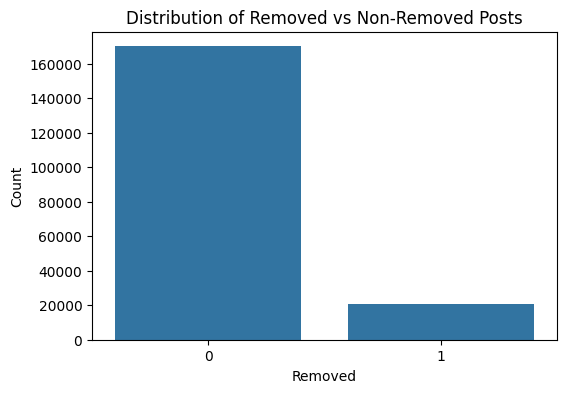

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="removed",
    data=df_clean
)

plt.title("Distribution of Removed vs Non-Removed Posts")
plt.xlabel("Removed")
plt.ylabel("Count")

plt.show()

# Class Distribution Analysis

## Observation

The dataset exhibits a significant class imbalance between removed and non-removed posts.

The majority of posts remain active, while only a relatively small proportion are removed by moderators. This indicates that removal events are comparatively rare within the dataset.

## Interpretation

Class imbalance can bias machine learning models toward predicting the majority class, leading to high accuracy but poor detection of removed posts. As a result, standard accuracy alone is not an adequate evaluation metric for this problem.

To address this issue, Synthetic Minority Oversampling Technique (SMOTE) was applied during model training to balance the classes and improve the model's ability to identify removed posts.

## Conclusion

The highly imbalanced nature of the target variable highlights the importance of using techniques such as SMOTE and evaluation metrics like Precision, Recall, and F1-score. Handling class imbalance was a critical step in developing an effective moderation prediction model.

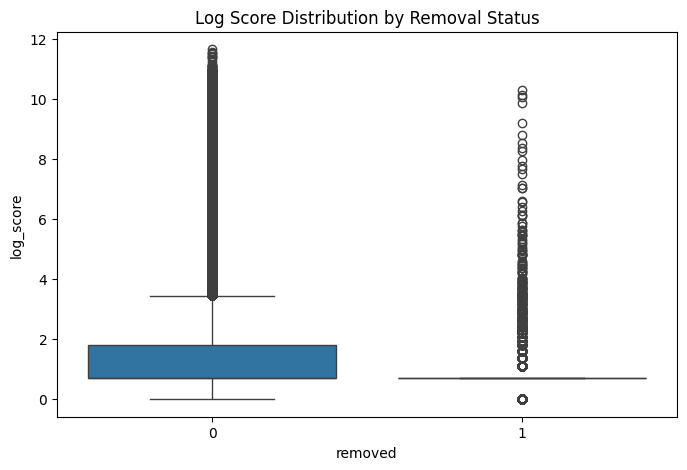

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="removed",
    y="log_score",
    data=df_clean
)

plt.title("Log Score Distribution by Removal Status")

plt.show()

# Score Distribution by Removal Status

## Observation

The distribution of post scores differs substantially between removed and non-removed posts.

Non-removed posts generally achieve higher scores, as reflected by the higher median and broader distribution of log-transformed scores. In contrast, removed posts tend to receive significantly lower scores and exhibit less community approval.

Although a few removed posts achieve high scores, they represent rare exceptions rather than the overall trend.

## Interpretation

Post score serves as a measure of community reception and popularity. The observed pattern suggests that posts receiving stronger positive feedback are more likely to remain active, whereas low-scoring posts face a greater likelihood of removal.

## Conclusion

The score distribution supports earlier EDA findings and feature importance analysis, where score emerged as one of the strongest metadata predictors of moderation outcomes. This indicates that community approval provides valuable information for predicting post removal.

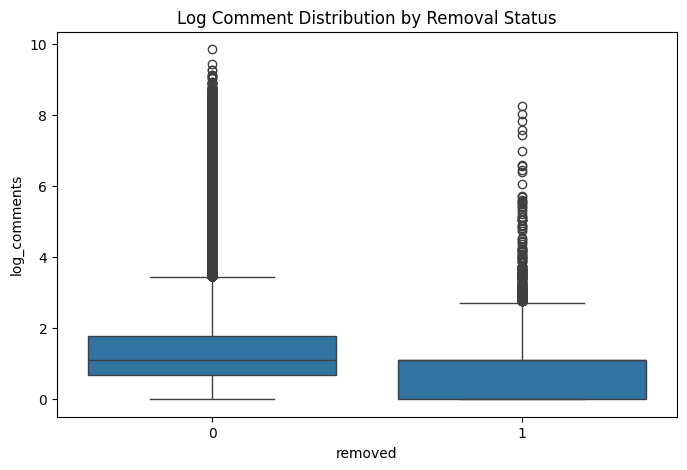

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="removed",
    y="log_comments",
    data=df_clean
)

plt.title("Log Comment Distribution by Removal Status")

plt.show()

# Comment Distribution by Removal Status

## Observation

The distribution of comment counts differs noticeably between removed and non-removed posts.

Non-removed posts generally receive a higher number of comments, as indicated by the higher median and wider distribution of log-transformed comment counts.

In contrast, removed posts tend to receive fewer comments and exhibit lower overall engagement.

## Interpretation

Community engagement appears to be associated with moderation outcomes. Posts that generate discussion and interaction are more likely to remain active, while posts with limited engagement have a higher probability of being removed.

## Conclusion

The observed pattern supports earlier EDA findings and feature importance results, where comment count emerged as one of the strongest metadata predictors of post removal. This suggests that community engagement provides valuable information for moderation prediction.

In [74]:
oc_removal = pd.crosstab(
    df_clean["has_oc"],
    df_clean["removed"],
    normalize="index"
) * 100

oc_removal

removed,0,1
has_oc,,
False,85.637625,14.362375
True,95.626573,4.373427


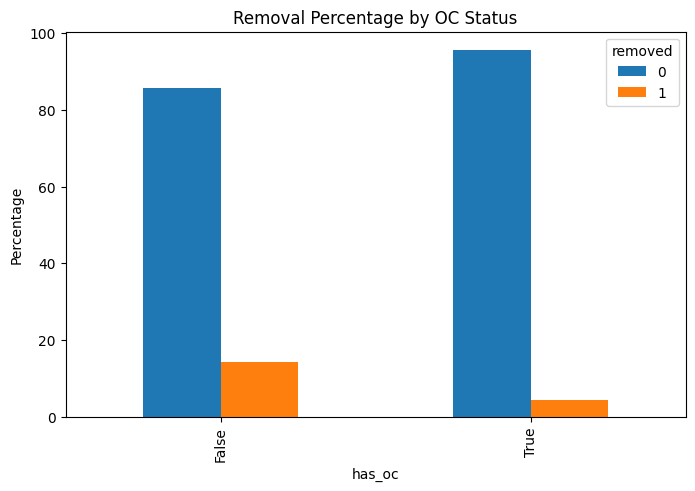

In [75]:
oc_removal.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Removal Percentage by OC Status")
plt.ylabel("Percentage")

plt.show()

# Impact of Original Content (OC) on Post Removal

## Observation

The removal rate differs significantly between Original Content (OC) and non-OC posts.

- Non-OC posts exhibit a removal rate of approximately **14%**.
- OC posts exhibit a removal rate of approximately **4–5%**.

## Interpretation

Posts marked as Original Content are substantially less likely to be removed. This suggests that original contributions tend to align better with subreddit guidelines and quality standards.

## Conclusion

The OC indicator provides meaningful predictive information and was identified as one of the most important metadata features in the Random Forest model. This finding highlights the importance of original content in influencing moderation outcomes.

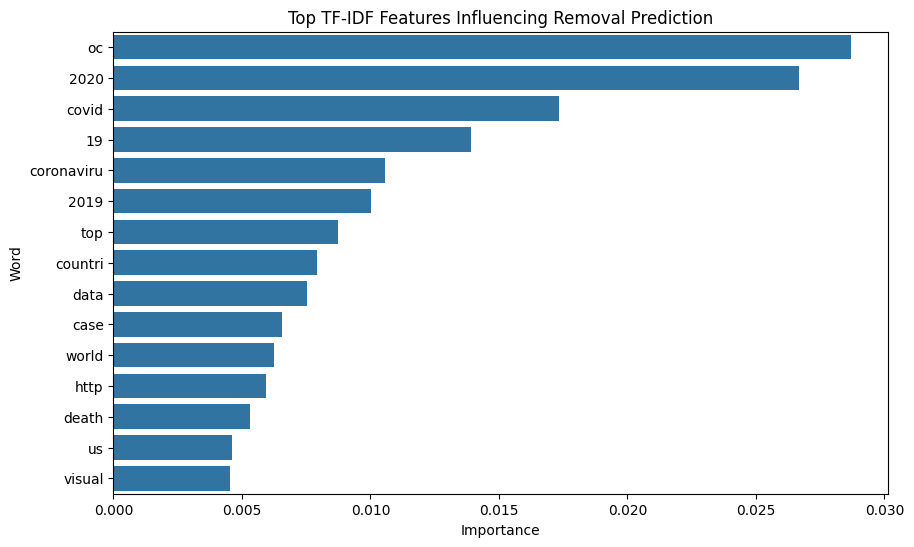

In [76]:
top15 = top_words.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Word",
    data=top15
)

plt.title("Top TF-IDF Features Influencing Removal Prediction")

plt.show()

# Text Feature Importance Analysis

## Objective

To understand which textual patterns contribute most significantly to the prediction of Reddit post removals.

## Methodology

After preprocessing the title text through tokenization, stop-word removal, and stemming, TF-IDF vectorization was applied to convert textual information into numerical features. A Random Forest classifier was then trained on the resulting feature matrix, and feature importance scores were extracted to identify the words that most strongly influenced model predictions.

## Results

The most influential textual features identified by the model include:

- oc
- 2020
- covid
- 19
- coronaviru
- 2019
- countri
- top
- case
- data
- world
- death
- http
- visual
- map

Among these, **"oc" (Original Content)** emerged as the most important feature, indicating that posts explicitly marked as original content exhibit distinct moderation patterns compared to other submissions.

Several highly ranked terms are related to the COVID-19 pandemic, including **covid**, **coronaviru**, **case**, **death**, **2019**, and **2020**. This suggests that pandemic-related discussions formed a major portion of the dataset and influenced moderation decisions during the data collection period.

The model also identified subreddit-specific visualization terms such as **data**, **visual**, **map**, **world**, and **countri**, reflecting the nature of content commonly posted within r/dataisbeautiful.

## Interpretation

The importance rankings demonstrate that the classifier is learning meaningful semantic patterns rather than relying on random vocabulary. The presence of topic-specific terms indicates that certain subjects and posting styles are more strongly associated with moderation outcomes.

Additionally, the prominence of the **OC** tag suggests that original contributions are treated differently from reposted or externally sourced content, making it a valuable predictor for the classification task.

## Conclusion

The feature importance analysis confirms that textual content plays a significant role in predicting whether a Reddit post will be removed. Terms related to Original Content, global events, and data visualization topics contribute substantially to the model's decision-making process. These findings highlight the effectiveness of TF-IDF vectorization in capturing interpretable linguistic signals relevant to Reddit moderation behavior.

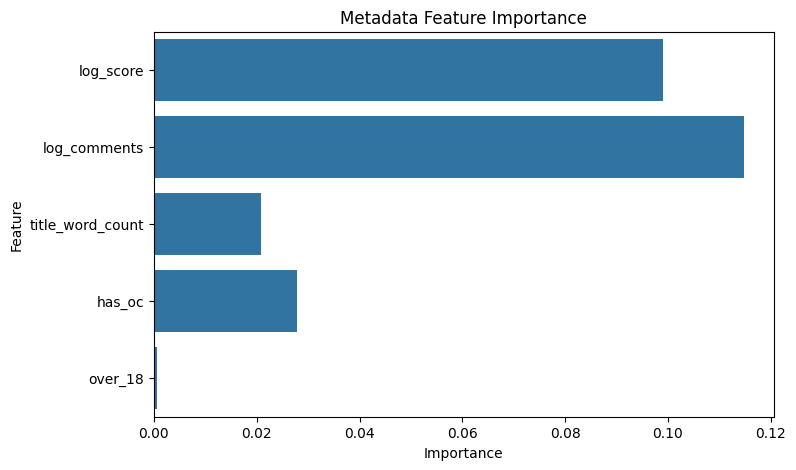

In [77]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=num_importance
)

plt.title("Metadata Feature Importance")

plt.show()

# Metadata Feature Importance Analysis

## Objective

To identify which engineered metadata features contribute most significantly to the Random Forest model's prediction of Reddit post removals.

## Methodology

Feature importance scores were extracted from the trained Random Forest classifier. Higher impurity-based importance values indicate greater contribution to the model's tree splits. They do not establish causation or indicate whether a feature increases or decreases removal probability.

The analyzed metadata features include:

- Log-transformed post score
- Log-transformed comment count
- Title word count
- Original Content (OC) indicator
- NSFW indicator (over_18)

## Interpretation

The relative importance values can be used to identify which metadata variables the model relies on most heavily. The numerical values and ordering are shown in the table and plot above.


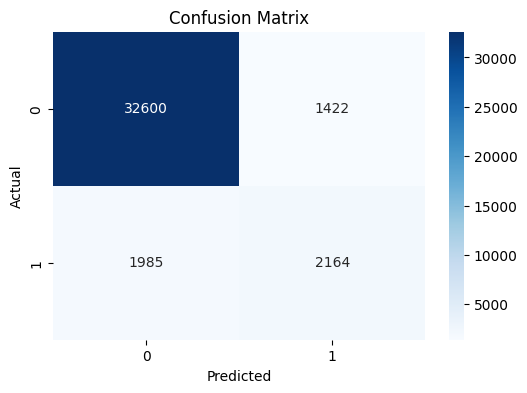

In [78]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_smote
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Confusion Matrix Analysis

## Objective

To evaluate the classification performance of the Random Forest model on unseen Reddit posts.

## Interpretation

The confusion matrix above shows the counts of true negatives, false positives, false negatives, and true positives. It provides a more detailed view of the model's performance than accuracy alone, particularly because the target classes are imbalanced.

False negatives represent recorded removals that the model did not identify, while false positives represent posts predicted as removed that were not recorded as removed.


In [79]:
from sklearn.decomposition import TruncatedSVD

# Use a random sample from the training data for visualization
rng = np.random.RandomState(42)
n_svd = min(5000, X_train_combined.shape[0])
svd_idx = rng.choice(X_train_combined.shape[0], size=n_svd, replace=False)

X_svd = X_train_combined[svd_idx].tocsr()

svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_2d = svd.fit_transform(X_svd)


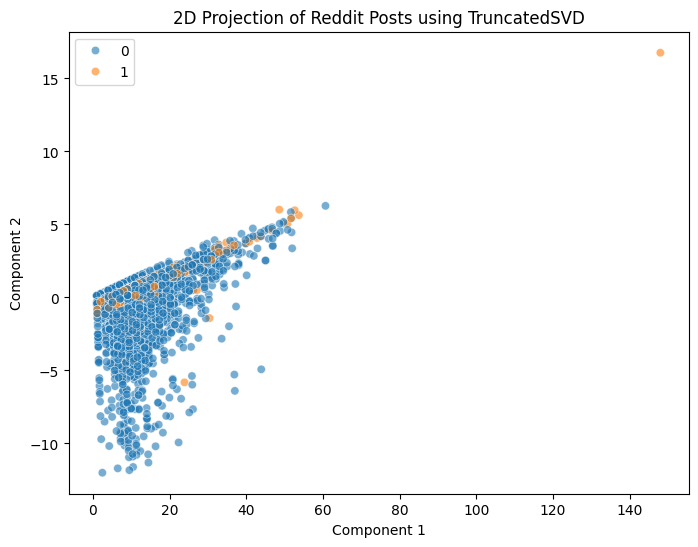

In [80]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=y_train.iloc[svd_idx].to_numpy(),
    alpha=0.6
)

plt.title("2D Projection of Reddit Posts using TruncatedSVD")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()


In [81]:
svd.explained_variance_ratio_

array([0.90668458, 0.0624759 ])

# TruncatedSVD Results

## Explained Variance

The explained variance ratios are displayed by the cell above. Because the visualization uses a random sample of the training data, these values describe that sampled training representation rather than the entire dataset.

## Interpretation

TruncatedSVD provides a two-dimensional representation of the high-dimensional sparse feature space for visualization. The explained variance indicates how much variation in the sampled feature space is captured by the two components.


# Final Conclusion

## Project Overview

The objective of this project was to analyze Reddit posts and build a machine learning system capable of predicting whether a post has a recorded removal/deletion outcome. The project combined exploratory data analysis, natural language processing, feature engineering, and supervised machine learning to identify patterns associated with recorded removal outcomes.

---

## Key Findings from EDA

- The dataset exhibited significant class imbalance, with non-removed posts greatly outnumbering removed posts.
- Posts with higher scores and greater community engagement (comment counts) showed lower recorded removal rates in this dataset.
- Original Content (OC) posts showed a lower recorded removal rate compared to non-OC posts.
- Metadata features such as post score and comment count showed useful associations with the recorded removal outcome.
- Correlation analysis indicated a moderate positive relationship between score and comment count, while correlations with removal status were generally weak.

---

## NLP and Feature Engineering

To extract meaningful information from post titles:

- Text was cleaned through lowercasing, tokenization, stop-word removal, and stemming.
- TF-IDF vectorization was applied to convert textual content into numerical representations.
- Additional metadata features were engineered, including:
  - Log-transformed post score
  - Log-transformed comment count
  - Title word count
  - Original Content (OC) indicator
  - NSFW indicator

These features were combined to create a comprehensive representation of each Reddit post.

---

## Machine Learning Approach

Several classification models were explored, including Decision Tree and Random Forest models. Class imbalance was handled using class weighting and SMOTE during model training.

Model performance should be evaluated using the metrics and confusion matrices produced by the notebook, with particular attention to precision, recall, and F1-score in addition to accuracy.

---

## Model Interpretation

Feature importance analysis was used to identify textual and metadata features that the Random Forest relies on for prediction. These importance values describe model behavior and should not be interpreted as evidence that a feature causes removal or that a particular feature always increases or decreases removal probability.

---

## Dimensionality Reduction

TruncatedSVD was applied to a random sample of the training feature matrix to visualize the high-dimensional sparse feature space in two dimensions. The explained variance ratios shown by the notebook describe this sampled representation.

---

## Project Outcomes

This project demonstrates an end-to-end data science workflow:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Feature Engineering
- Natural Language Processing (NLP)
- TF-IDF Vectorization
- Handling Class Imbalance
- Machine Learning Classification
- Model Evaluation
- Feature Importance Analysis
- Dimensionality Reduction and Visualization

---

## Future Improvements

Potential enhancements include:

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Experimentation with advanced NLP techniques such as Word2Vec, FastText, or Transformer-based embeddings.
- Integration of Large Language Models (LLMs) for explainable moderation predictions.
- Deployment as a real-time moderation assistance tool using a web application framework.


